In [1]:
import os
import random
from pathlib import Path
from PIL import Image
import numpy as np
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import torchvision.models as models
import torch.nn.functional as F
import torch.nn as nn
import torch


In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")


In [3]:

train_dir = "./dataset/train"
val_dir = "./dataset/val"
test_dir = "./dataset/test"

print(os.listdir(train_dir))

['tuberculosis', 'pneumonia', 'normal']


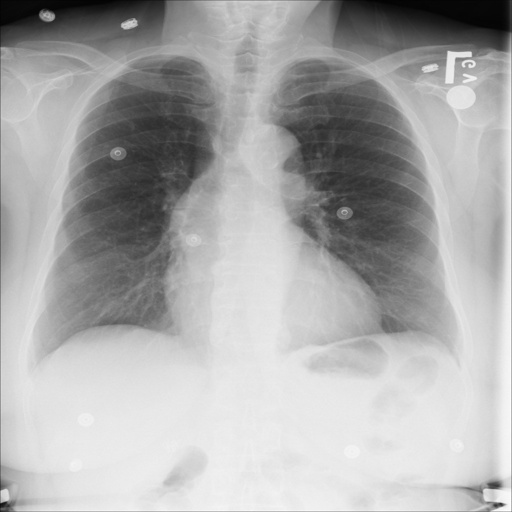

In [4]:
random.seed(42)
base_dir = Path(train_dir)

image_path_list = list(base_dir.glob("*/*.jpg"))

random_image_path = random.choice(image_path_list)

image_class = os.path.basename(os.path.dirname(random_image_path))

img = Image.open(random_image_path) 
img

In [5]:
data_transform = transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ToTensor(),
])

    
    

In [6]:
train_data = datasets.ImageFolder(
    root=train_dir,
    transform = data_transform,
    target_transform = None)

test_data = datasets.ImageFolder(
    root= test_dir,
    transform = data_transform)

val_data = datasets.ImageFolder(
    root= val_dir,
    transform = data_transform)

    

In [7]:

# Get class names as a list
class_names = train_data.classes
class_names

['normal', 'pneumonia', 'tuberculosis']

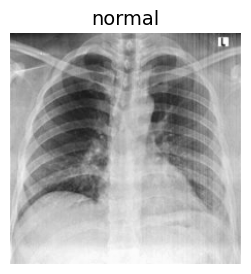

In [8]:
img_train, label_train = train_data[1][0], train_data[0][1]

img_train_permute = img_train.permute(1, 2, 0)
plt.figure(figsize=(4, 3))
plt.imshow(img_train_permute,cmap="gray")
plt.axis("off")
plt.title(class_names[label_train], fontsize=14);


In [9]:

train_dataloader = DataLoader(train_data, batch_size=128, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=128, shuffle=False)
val_dataloader = DataLoader(val_data, batch_size=128, shuffle=False)


In [10]:
class ImageClassificationBase(nn.Module):
    
    def training_step(self, batch):
        images, labels = batch 
        images = images.to(device)  # Add this
        labels = labels.to(device)  
        out = self(images)                  # Generate predictions
        loss = F.cross_entropy(out, labels) # Calculate loss
        return loss
    
    def validation_step(self, batch):
        images, labels = batch 
        images = images.to(device)  # Add this
        labels = labels.to(device)  # Add this
        out = self(images)                    # Generate predictions
        loss = F.cross_entropy(out, labels)   # Calculate loss
        acc = accuracy(out, labels)           # Calculate accuracy
        return {'val_loss': loss.detach(), 'val_acc': acc}
        
    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}
    
    def epoch_end(self, epoch, result):
        print("Epoch [{}], train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
        epoch, result['train_loss'], result['val_loss'], result['val_acc']), flush=True)

In [11]:
class ChestXrayClassification(ImageClassificationBase):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            
            nn.Flatten(),
            nn.Linear(100352, 256),  # Daha küçük
            nn.ReLU(),
            nn.Linear(256, 6)
        )
    
    def forward(self, xb):
        return self.network(xb)

In [12]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

  
@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

  
def fit(epochs, lr, model, train_loader, val_loader, opt_func = torch.optim.SGD):
    
    history = []
    optimizer = opt_func(model.parameters(),lr)
    for epoch in range(epochs):
        
        model.train()
        train_losses = []
        for batch in train_loader:
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        model.epoch_end(epoch, result)
        history.append(result)
    
    return history

In [13]:
num_epochs = 3
opt_func = torch.optim.Adam
lr = 0.001
#fitting the model on training data and record the result after each epoch
model = ChestXrayClassification().to(device)

history = fit(num_epochs, lr, model, train_dataloader, val_dataloader, opt_func)

Epoch [0], train_loss: 0.6462, val_loss: 0.5249, val_acc: 0.7292
Epoch [1], train_loss: 0.5201, val_loss: 0.4985, val_acc: 0.7335
Epoch [2], train_loss: 0.4886, val_loss: 0.5014, val_acc: 0.7207


Device: mps

TEST DATASET RESULTS
Total images: 2569
Correct predictions: 1848
Incorrect predictions: 721
Accuracy: 0.7193 (71.93%)

Confusion Matrix:
Actual/Pred normal  pneumonitubercul
normal      566     93      266     
pneumonia   68      498     14      
tuberculosis276     4       784     

Per-Class Performance:
Class        TP     FP     FN     Precision  Recall     F1        
-----------------------------------------------------------------
normal       566    344    359    0.6220     0.6119     0.6169    
pneumonia    498    97     82     0.8370     0.8586     0.8477    
tuberculosis 784    280    280    0.7368     0.7368     0.7368    


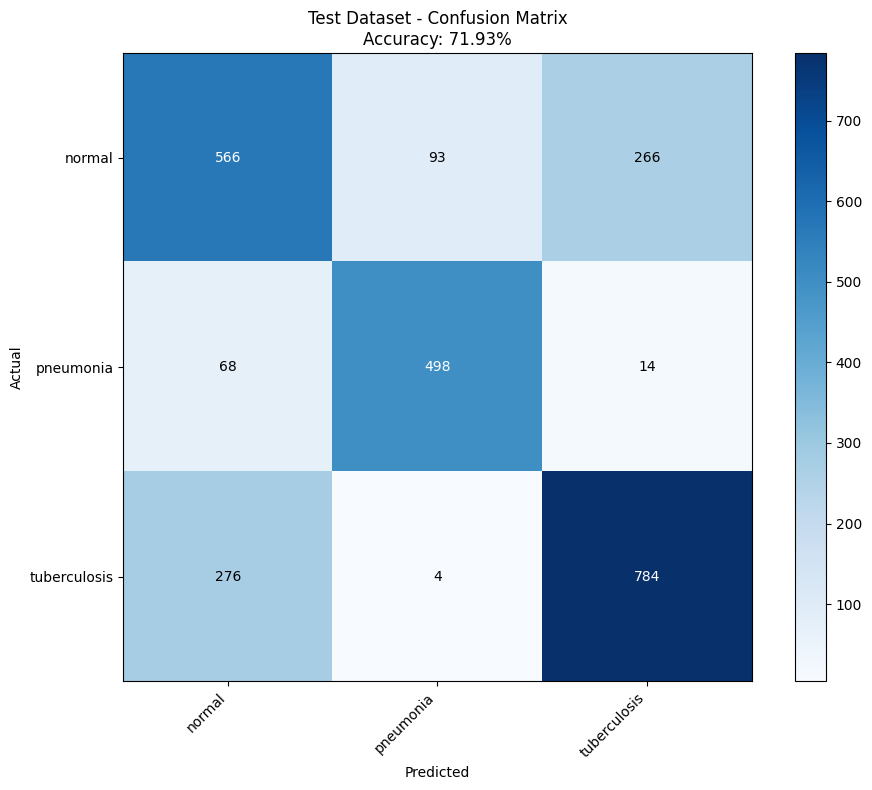


Confusion matrix saved as 'test_confusion_matrix.png'.


In [17]:
# ========== TEST DATASET EVALUATION ==========
import matplotlib.pyplot as plt
import torch

# Test function
@torch.no_grad()
def evaluate_test(model, test_loader, device=None):
    model.eval()
    all_preds = []
    all_labels = []
    
    for batch in test_loader:
        images, labels = batch
        if device:
            images = images.to(device)
            labels = labels.to(device)
        
        outputs = model(images)
        _, preds = torch.max(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    return all_preds, all_labels

# Determine device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

# Move model to device
model = model.to(device)

# Evaluate with test dataset
predictions, true_labels = evaluate_test(model, test_dataloader, device)

# Calculate accuracy
correct = sum(p == l for p, l in zip(predictions, true_labels))
accuracy = correct / len(true_labels)

print(f"\n{'='*50}")
print(f"TEST DATASET RESULTS")
print(f"{'='*50}")
print(f"Total images: {len(true_labels)}")
print(f"Correct predictions: {correct}")
print(f"Incorrect predictions: {len(true_labels) - correct}")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"{'='*50}")

# Confusion Matrix (manual calculation)
num_classes = len(class_names)
cm = [[0] * num_classes for _ in range(num_classes)]

for pred, true in zip(predictions, true_labels):
    cm[true][pred] += 1

print(f"\nConfusion Matrix:")
print(f"{'Actual/Pred':<12}", end='')
for name in class_names:
    print(f"{name[:8]:<8}", end='')
print()

for i, row in enumerate(cm):
    print(f"{class_names[i]:<12}", end='')
    for val in row:
        print(f"{val:<8}", end='')
    print()

# Per-class metrics (manual calculation)
print(f"\nPer-Class Performance:")
print(f"{'Class':<12} {'TP':<6} {'FP':<6} {'FN':<6} {'Precision':<10} {'Recall':<10} {'F1':<10}")
print("-" * 65)

for i, class_name in enumerate(class_names):
    tp = cm[i][i]  # True Positive
    fp = sum(cm[r][i] for r in range(num_classes)) - tp  # False Positive
    fn = sum(cm[i]) - tp  # False Negative
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"{class_name:<12} {tp:<6} {fp:<6} {fn:<6} {precision:<10.4f} {recall:<10.4f} {f1:<10.4f}")

# Confusion Matrix visualization
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow([[cm[i][j] for j in range(num_classes)] for i in range(num_classes)], 
               cmap='Blues')

ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Test Dataset - Confusion Matrix\nAccuracy: {accuracy*100:.2f}%')

# Write values in cells
for i in range(num_classes):
    for j in range(num_classes):
        text = ax.text(j, i, cm[i][j], ha="center", va="center", 
                      color="white" if cm[i][j] > max(max(row) for row in cm) / 2 else "black")

plt.colorbar(im)
plt.tight_layout()
plt.savefig('test_confusion_matrix.png', dpi=150)
plt.show()

print(f"\nConfusion matrix saved as 'test_confusion_matrix.png'.")